In [8]:
# 1. Setup
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PROCESSED_PATH = "./data/processed/"
sns.set(style="whitegrid")


In [9]:
# 2. Load processed data
transactions = pd.read_csv(os.path.join(DATA_PROCESSED_PATH, "SAML-D_clean.csv"))
transactions.head()


,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type,Datetime
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits,2022-10-07 10:35:19
1,10:35:31,2022-10-07,5119661534,9734073275,2342.31,UK pounds,UK pounds,UK,UK,Debit card,0,Normal_Small_Fan_Out,2022-10-07 10:35:31
2,10:35:46,2022-10-07,3709430533,9172843471,5274.76,UK pounds,UK pounds,UK,UK,Debit card,0,Normal_Fan_Out,2022-10-07 10:35:46
3,10:36:05,2022-10-07,1203252958,8500212178,2438.30,UK pounds,Mexican Peso,UK,Mexico,Cross-border,0,Normal_Group,2022-10-07 10:36:05
4,10:36:34,2022-10-07,7669236826,6044424887,8560.28,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_Out,2022-10-07 10:36:34


In [10]:
# 2. Load processed data
transactions = pd.read_csv(os.path.join(DATA_PROCESSED_PATH, "SAML-D_clean.csv"))

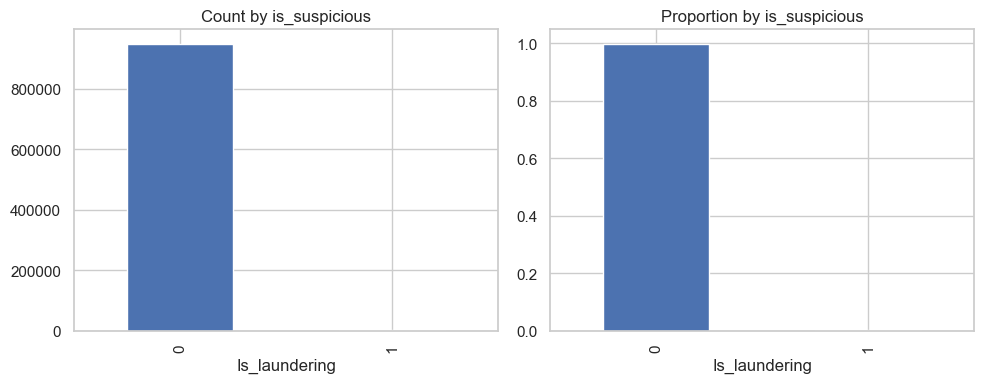

In [ ]:
# 3. Target distribution
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
transactions["Is_laundering"].value_counts().plot(kind="bar", ax=ax[0], title="Count by Laundering")
transactions["Is_laundering"].value_counts(normalize=True).plot(kind="bar", ax=ax[1], title="Proportion by Laundering")
plt.tight_layout()

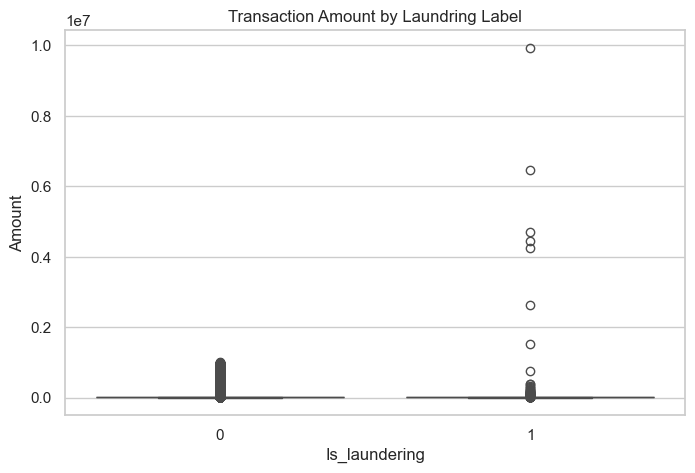

In [13]:
# 4. Amount distribution by label
plt.figure(figsize=(8, 5))
sns.boxplot(data=transactions, x="Is_laundering", y="Amount")
plt.title("Transaction Amount by Laundring Label")
plt.show()

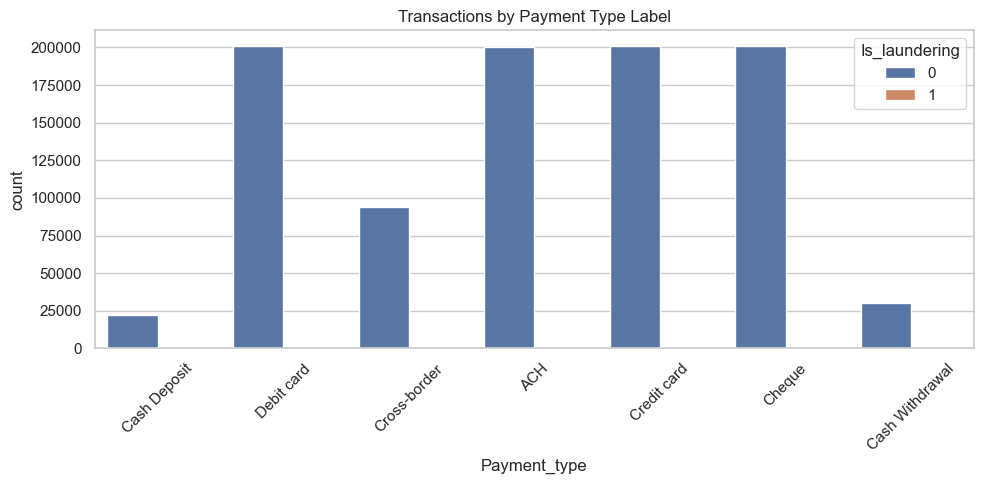

In [21]:
# 5. Payment type and region analysis (adjust column names)
plt.figure(figsize=(10, 5))
sns.countplot(data=transactions, x="Payment_type", hue="Is_laundering")
plt.xticks(rotation=45)
plt.title("Transactions by Payment Type Label")
plt.tight_layout()
plt.show()

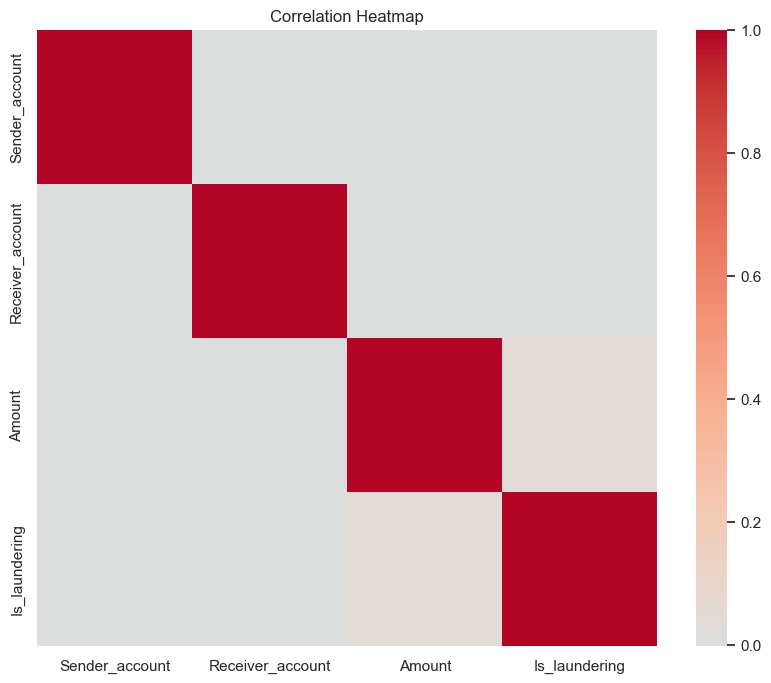

In [16]:
# 6. Correlation analysis (numeric features only)
numeric_cols = transactions.select_dtypes(include=[np.number]).columns
corr = transactions[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

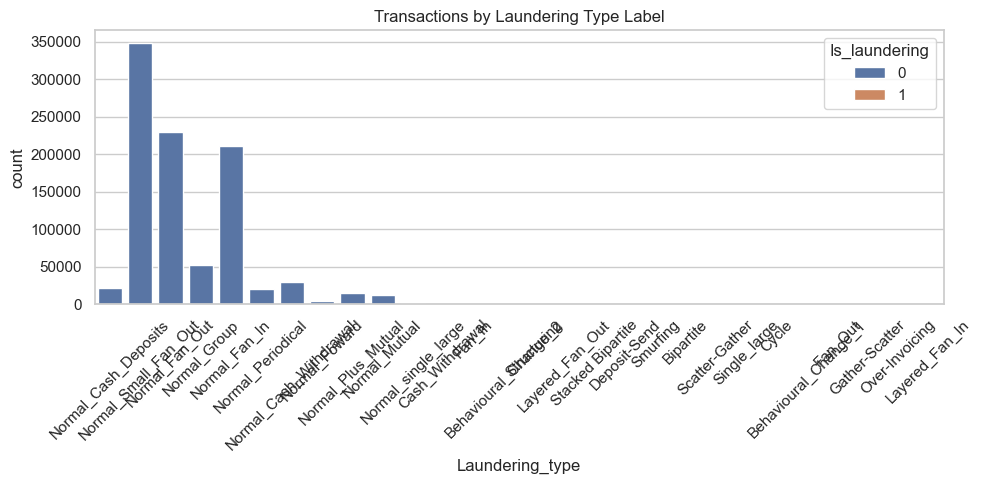

In [ ]:
# 7. Laundering type and region analysis (adjust column names)
plt.figure(figsize=(10, 5))
sns.countplot(data=transactions, x="Laundering_type", hue="Is_laundering")
plt.xticks(rotation=45)
plt.title("Transactions by Laundering Type Label")
plt.tight_layout()
plt.show()